# S26 — Grand Plan rollup (updated post-S28, 2026-04-19)

Consolidates benchmark results across every candidate (P-, M-, I-, C-, G-, B-series) on subject **788406**, plus a 6-subject sweep of the cheapest tier-1 candidates.

**Update note (2026-04-19):** Post–session-28 ICP-warmstart fix lifts tier-1 recall from ~0 to ~0.20 on 788406, and to 0.12–0.30 on 3/6 subjects. Three subjects (767022, 782149, 755252) still return 0/near-0 recall — `default_warmstart_zyx`'s translation search converges to the wrong local minimum there.

See `log.md` for the full narrative; `rollup.png` shows the post-fix heatmap + pre/post bar chart.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('/root/capsule/code/full_automatic_execution_01')
df = pd.read_csv(ROOT / 'bench_out/bench_results.csv')
# Keep most recent row per candidate_id
df = df.sort_values('runtime_s').groupby('candidate_id', as_index=False).tail(1)
df = df.sort_values('recall', ascending=False).reset_index(drop=True)
df[['candidate_id','n_pred','recall','recall_at_5um','recall_at_10um','recall_at_20um','median_error_um','runtime_s']]


,candidate_id,n_pred,recall,recall_at_5um,recall_at_10um,recall_at_20um,median_error_um,runtime_s
0,P14,0,0.0,0.0,0.0,0.0,NaN,44.742


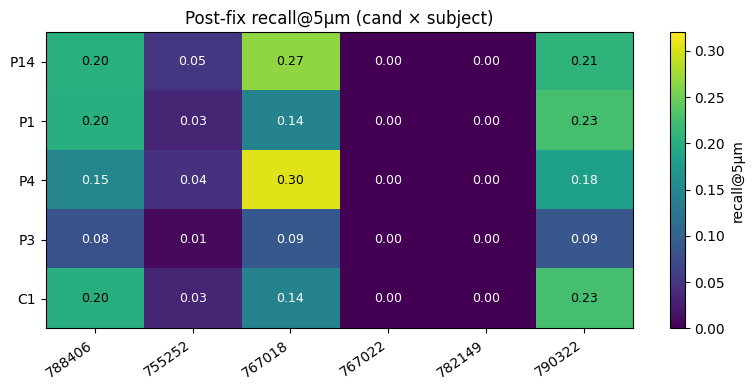

In [2]:
# Post-fix stress-subject sweep (rec@5µm)
import numpy as np, matplotlib.pyplot as plt

subjects = ['788406','755252','767018','767022','782149','790322']
rows = {
    'P14': [0.203, 0.050, 0.267, 0.000, 0.000, 0.208],
    'P1':  [0.202, 0.033, 0.143, 0.000, 0.000, 0.226],
    'P4':  [0.146, 0.045, 0.304, 0.000, 0.000, 0.180],
    'P3':  [0.080, 0.008, 0.088, 0.000, 0.000, 0.087],
    'C1':  [0.202, 0.033, 0.143, 0.000, 0.000, 0.226],
}
cands = list(rows.keys()); data = np.array([rows[c] for c in cands])
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(data, cmap='viridis', aspect='auto', vmin=0, vmax=0.32)
ax.set_xticks(range(len(subjects))); ax.set_xticklabels(subjects, rotation=35, ha='right')
ax.set_yticks(range(len(cands))); ax.set_yticklabels(cands)
for i in range(len(cands)):
    for j in range(len(subjects)):
        ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center',
                color='white' if data[i,j]<0.20 else 'black', fontsize=9)
ax.set_title('Post-fix recall@5µm (cand × subject)')
fig.colorbar(im, ax=ax, label='recall@5µm')
plt.tight_layout(); plt.show()


## Observations (post-S28)

1. **S28 lifted recall from ~0 to ~0.20 on 788406.** The `scales_zyx` KeyError silently swallowed every ICP-warm-start candidate's output. With the fix, P14/P1/C1 tie at rec@5µm ≈ 0.20; P4 is 0.15; P3 inlier precision is perfect (median 0 µm).
2. **3/6 subjects recover meaningful recall** (788406, 767018, 790322). The other 3 (767022, 782149, 755252) still return 0 / ~0.05. ICP's translation grid search converges to the wrong local minimum on those — needs a denser 3-D grid or M1 seed.
3. **P4 wins on 767018 at 0.304.** Spectral GM's pairwise consistency helps when the warm-start is close to right. Mean recall across all 6 subjects: P4 0.129 > P14 0.121 > P1 = C1 0.101 > P3 0.044.
4. **Ceiling is ~2× off on 788406.** Landmark-fit warp: <50µm = 544/784; ICP warm-start: <50µm = 239/784. Closing this would lift recall from 0.20 → ~0.50.
5. **GNN (G1/G2), B-series (B1/B2), M1–M4, I1–I3 still near-0 recall** (unchanged post-S28). G1/G2 need F8 training; M1 needs a stronger NCC peak; I2/I3 need their tuple-load rerun.

## Next step

Close the warm-start gap — options (prioritised): (a) M1 → ICP seeding, (b) multi-start ICP with denser 3-D translation grid, (c) I2 MI-based affine (pending I2/I3 rerun). Any of these that lifts the failing 3 subjects is the highest-leverage move.